In [2]:
from photometry.models.lambertian import LambertianModel
from photometry.fitting.least_sq import LeastSquaresFitter
from photometry.core.types import GeometryBatch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path

import os
print(os.getcwd())

/home/kaushim07/photometry_mcmc_env/notebooks


In [4]:
model = LambertianModel()
fitter = LeastSquaresFitter()

In [5]:
project_root = Path.cwd().resolve()
if not (project_root / "data").exists() and (project_root.parent / "data").exists():
    project_root = project_root.parent

data_root = project_root / "data" / "05_aggregated"
phase_order = {"survey": 0, "hamo": 1, "lamo": 2, "rc": 3}

csv_files = sorted(
    data_root.glob("*_phase_curve.csv"),
    key=lambda path: (phase_order.get(path.stem.replace("_phase_curve", "").lower(), 99), path.name),
)
if not csv_files:
    raise FileNotFoundError(f"No csv files found in {data_root}")

phase_groups = {phase: [] for phase in phase_order}
for path in csv_files:
    phase = path.stem.replace("_phase_curve", "").lower()
    if phase in phase_groups:
        phase_groups[phase].append(path)

phase_dfs = {}
phase_best_file = {}
for phase in ["survey", "hamo", "lamo", "rc"]:
    files = phase_groups.get(phase, [])
    if not files:
        phase_dfs[phase] = pd.DataFrame()
        phase_best_file[phase] = None
        continue

    best_path = max(files, key=lambda p: p.stat().st_size)
    phase_best_file[phase] = best_path
    phase_dfs[phase] = pd.read_csv(best_path)

df_survey = phase_dfs["survey"]
df_hamo = phase_dfs["hamo"]
df_lamo = phase_dfs["lamo"]
df_rc = phase_dfs["rc"]


df = df_survey
if df.empty:
    for phase in ["survey", "hamo", "lamo", "rc"]:
        if not phase_dfs[phase].empty:
            df = phase_dfs[phase]
            break

print(f"Project root: {project_root}")
print(f"Aggregated data root: {data_root}")
print(f"Files discovered: {len(csv_files)}")
for phase in ["survey", "hamo", "lamo", "rc"]:
    phase_df = phase_dfs[phase]
    best_file = phase_best_file[phase]
    print(f"{phase.upper()}: files={len(phase_groups[phase])}, rows={len(phase_df):,}")
    if best_file is not None:
        print(f"  representative file: {best_file.name}")

Project root: /home/kaushim07/photometry_mcmc_env
Aggregated data root: /home/kaushim07/photometry_mcmc_env/data/05_aggregated
Files discovered: 4
SURVEY: files=1, rows=90
  representative file: survey_phase_curve.csv
HAMO: files=1, rows=90
  representative file: hamo_phase_curve.csv
LAMO: files=1, rows=70
  representative file: lamo_phase_curve.csv
RC: files=1, rows=61
  representative file: rc_phase_curve.csv


In [6]:
df_rc = df_rc[df_rc['median_iof'] > 0.01].dropna() # Filter out low I/F values and drop NaNs

In [7]:
rc_mean_incidence_rad = df_rc["mean_incidence"].to_numpy(dtype=float) * (np.pi / 180.0)
rc_mean_emission_rad = df_rc["mean_emission"].to_numpy(dtype=float) * (np.pi / 180.0)
rc_mean_phase_rad = df_rc["mean_phase"].to_numpy(dtype=float) * (np.pi / 180.0)

rc_geometry_batch = GeometryBatch(
    incidence=rc_mean_incidence_rad,
    emission=rc_mean_emission_rad,
    phase=rc_mean_phase_rad,
)

model = LambertianModel()
fitter = LeastSquaresFitter()

rc_observed = df_rc["median_iof"].to_numpy(dtype=float)

rc_fit_result = fitter.fit(model, rc_geometry_batch, rc_observed)

rc_fitted_albedo = rc_fit_result.fitted_parameters["albedo"]


print("Fitted albedo:", rc_fitted_albedo)

model.parameters.update(rc_fit_result.fitted_parameters)
rc_predicted = np.asarray(model.reflectance(rc_geometry_batch), dtype=float)

Fitted albedo: 0.5013534291225069


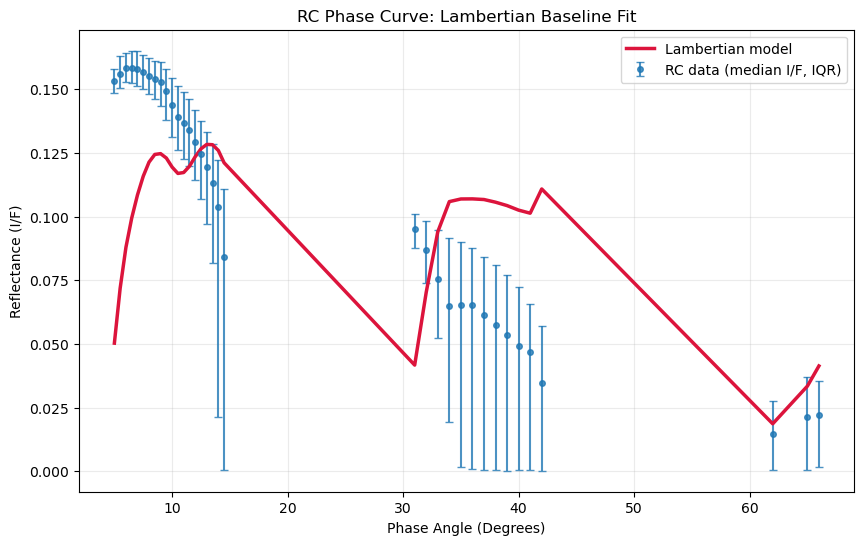

In [8]:
rc_x = df_rc["phase_bin_deg"].to_numpy(dtype=float)
rc_order = np.argsort(rc_x)
rc_x_sorted = rc_x[rc_order]
rc_observed_sorted = rc_observed[rc_order]
rc_predicted_sorted = rc_predicted[rc_order]
rc_yerr_lower = (rc_observed - df_rc["iof_q25"].to_numpy(dtype=float))[rc_order]
rc_yerr_upper = (df_rc["iof_q75"].to_numpy(dtype=float) - rc_observed)[rc_order]
rc_yerr = np.vstack([rc_yerr_lower, rc_yerr_upper])

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(
    rc_x_sorted,
    rc_observed_sorted,
    yerr=rc_yerr,
    fmt="o",
    markersize=4,
    capsize=3,
    alpha=0.8,
    label="RC data (median I/F, IQR)",
)
ax.plot(
    rc_x_sorted,
    rc_predicted_sorted,
    color="crimson",
    linewidth=2.5,
    label="Lambertian model",
)

ax.set_xlabel("Phase Angle (Degrees)")
ax.set_ylabel("Reflectance (I/F)")
ax.set_title("RC Phase Curve: Lambertian Baseline Fit")
ax.legend()
ax.grid(True, alpha=0.25)

plt.show()

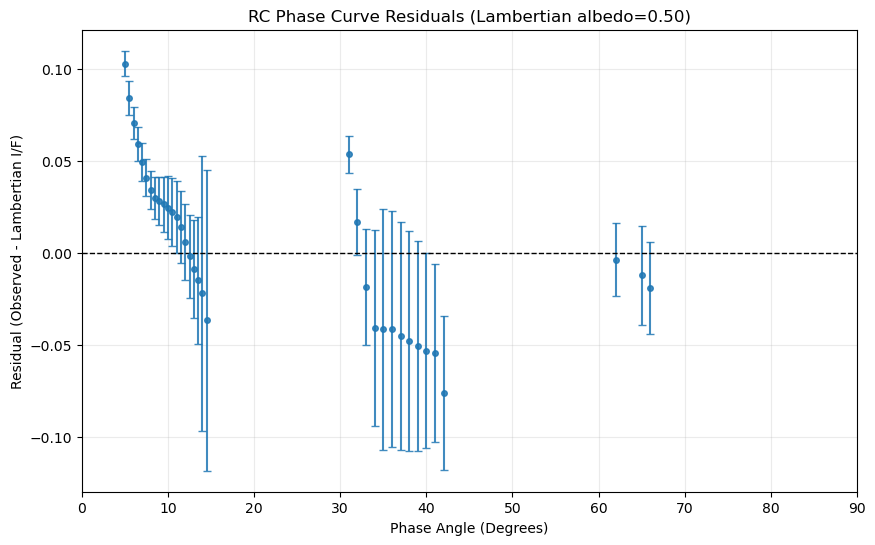

RC Mean residuals (I/F): <15deg=2.627696e-02, 15-45deg=-3.339617e-02, >45deg=-1.186738e-02


In [9]:
rc_mu0 = np.cos(rc_mean_incidence_rad)

# Lambertian predicted I/F = albedo * mu0 / pi
rc_pred_lambert = rc_fitted_albedo * rc_mu0 / np.pi
rc_observed = df_rc['median_iof'].to_numpy(dtype=float) # Convert to numpy array
rc_residuals = rc_observed - rc_pred_lambert


# Uncertainty estimate from IQR -> sigma ~= IQR / 1.35
rc_iqr = df_rc['iof_q75'].to_numpy(dtype=float) - df_rc['iof_q25'].to_numpy(dtype=float)
rc_sigma = rc_iqr / 1.35

# Plot residuals vs phase with symmetric error bars using sigma
rc_x = df_rc['phase_bin_deg'].to_numpy(dtype=float)
rc_order = np.argsort(rc_x)
rc_x_sorted = rc_x[rc_order]
rc_res_sorted = rc_residuals[rc_order]
rc_yerr = rc_sigma[rc_order]

fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(rc_x_sorted, rc_res_sorted, yerr=rc_yerr, fmt='o', markersize=4, capsize=3, alpha=0.85)
ax.axhline(0.0, color='k', linestyle='--', linewidth=1)
ax.set_xlim(0, 90)
ax.set_xlabel('Phase Angle (Degrees)')
ax.set_ylabel('Residual (Observed - Lambertian I/F)')
ax.set_title('RC Phase Curve Residuals (Lambertian albedo={:.2f})'.format(rc_fitted_albedo))
ax.grid(True, alpha=0.25)
plt.show()

# Compute mean residuals in three phase ranges

rc_mask1 = rc_x_sorted < 15
rc_mask2 = (rc_x_sorted >= 15) & (rc_x_sorted <= 45)
rc_mask3 = rc_x_sorted > 45
rc_mean1 = np.mean(rc_res_sorted[rc_mask1]) if np.any(rc_mask1) else np.nan
rc_mean2 = np.mean(rc_res_sorted[rc_mask2]) if np.any(rc_mask2) else np.nan
rc_mean3 = np.mean(rc_res_sorted[rc_mask3]) if np.any(rc_mask3) else np.nan
print(f"RC Mean residuals (I/F): <15deg={rc_mean1:.6e}, 15-45deg={rc_mean2:.6e}, >45deg={rc_mean3:.6e}")



## Survey 

In [21]:
df_survey = df_survey[df_survey['median_iof'] > 0.01].dropna()

survey_mean_incidence_rad = df_survey["mean_incidence"].to_numpy(dtype=float) * (np.pi / 180.0) # Convert degrees to radians
survey_mean_emission_rad = df_survey["mean_emission"].to_numpy(dtype=float) * (np.pi / 180.0) # Convert degrees to radians
survey_mean_phase_rad = df_survey["mean_phase"].to_numpy(dtype=float) * (np.pi / 180.0)     # Convert degrees to radians

survey_geometry_batch = GeometryBatch(
    incidence=survey_mean_incidence_rad,
    emission=survey_mean_emission_rad,
    phase=survey_mean_phase_rad,
)


survey_observed = df_survey["median_iof"].to_numpy(dtype=float)

survey_fit_result = fitter.fit(model, survey_geometry_batch, survey_observed)

survey_fitted_albedo = survey_fit_result.fitted_parameters["albedo"]

print("Fitted albedo survey:", survey_fitted_albedo)

model.parameters.update(survey_fit_result.fitted_parameters)
survey_predicted = np.asarray(model.reflectance(survey_geometry_batch), dtype=float)

Fitted albedo survey: 0.34548981724988226


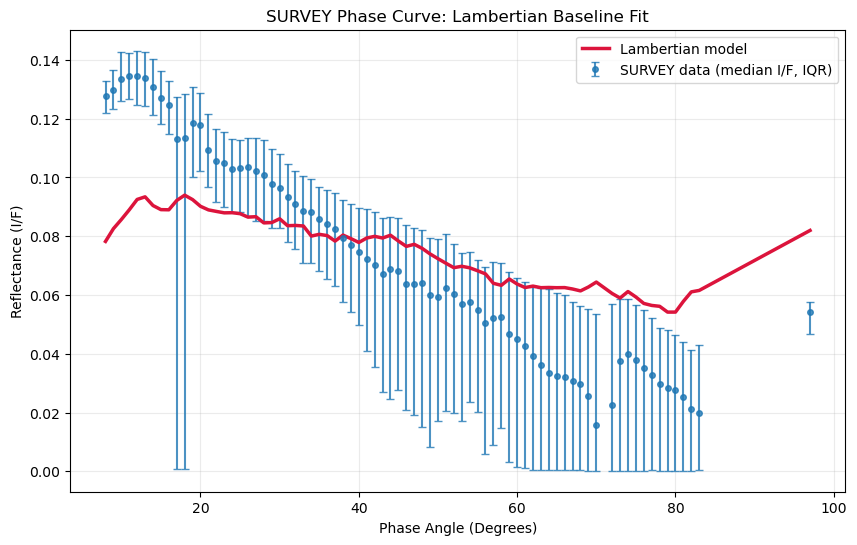

In [22]:
survey_x = df_survey["phase_bin_deg"].to_numpy(dtype=float)
survey_order = np.argsort(survey_x)
survey_x_sorted = survey_x[survey_order]
survey_observed_sorted = survey_observed[survey_order]
survey_predicted_sorted = survey_predicted[survey_order]
survey_yerr_lower = (survey_observed - df_survey["iof_q25"].to_numpy(dtype=float))[survey_order]
survey_yerr_upper = (df_survey["iof_q75"].to_numpy(dtype=float) - survey_observed)[survey_order]
survey_yerr = np.vstack([survey_yerr_lower, survey_yerr_upper])

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(
    survey_x_sorted,
    survey_observed_sorted,
    yerr=survey_yerr,
    fmt="o",
    markersize=4,
    capsize=3,
    alpha=0.8,
    label="SURVEY data (median I/F, IQR)",
)
ax.plot(
    survey_x_sorted,
    survey_predicted_sorted,
    color="crimson",
    linewidth=2.5,
    label="Lambertian model",
)

ax.set_xlabel("Phase Angle (Degrees)")
ax.set_ylabel("Reflectance (I/F)")
ax.set_title("SURVEY Phase Curve: Lambertian Baseline Fit")
ax.legend()
ax.grid(True, alpha=0.25)

plt.show()

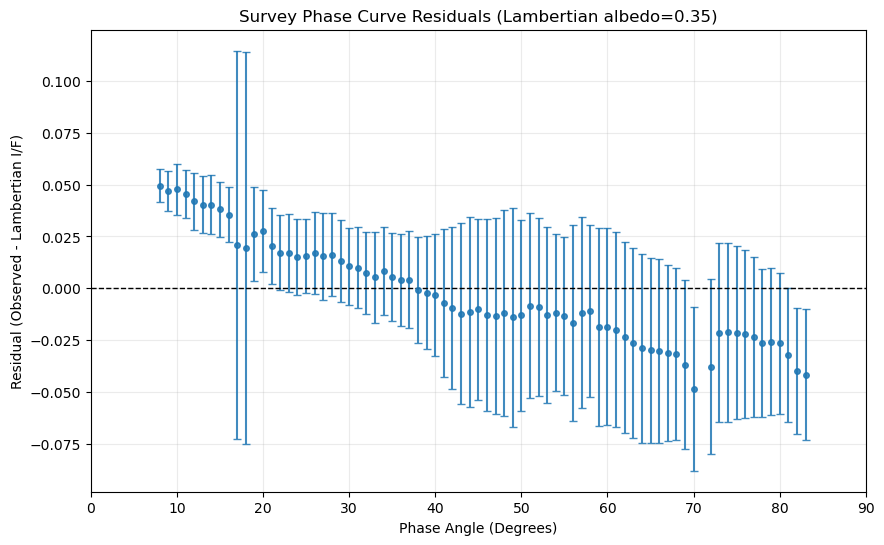

Survey Mean residuals (I/F): <15deg=4.469307e-02, 15-45deg=1.007132e-02, >45deg=-2.298481e-02


In [23]:


survey_mu0 = np.cos(survey_mean_incidence_rad)

# Lambertian predicted I/F = albedo * mu0 / pi
survey_pred_lambert = survey_fitted_albedo * survey_mu0 / np.pi
survey_observed = df_survey['median_iof'].to_numpy(dtype=float) # Convert to numpy array
survey_residuals = survey_observed - survey_pred_lambert


# Uncertainty estimate from IQR -> sigma ~= IQR / 1.35
survey_iqr = df_survey['iof_q75'].to_numpy(dtype=float) - df_survey['iof_q25'].to_numpy(dtype=float)
survey_sigma = survey_iqr / 1.35

# Plot residuals vs phase with symmetric error bars using sigma
survey_x = df_survey['phase_bin_deg'].to_numpy(dtype=float)
survey_order = np.argsort(survey_x)
survey_x_sorted = survey_x[survey_order]
survey_res_sorted = survey_residuals[survey_order]
survey_yerr = survey_sigma[survey_order]

fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(survey_x_sorted, survey_res_sorted, yerr=survey_yerr, fmt='o', markersize=4, capsize=3, alpha=0.85)
ax.axhline(0.0, color='k', linestyle='--', linewidth=1)
ax.set_xlim(0, 90)
ax.set_xlabel('Phase Angle (Degrees)')
ax.set_ylabel('Residual (Observed - Lambertian I/F)')
ax.set_title('Survey Phase Curve Residuals (Lambertian albedo={:.2f})'.format(survey_fitted_albedo))
ax.grid(True, alpha=0.25)
plt.show()

# Compute mean residuals in three phase ranges

survey_mask1 = survey_x_sorted < 15
survey_mask2 = (survey_x_sorted >= 15) & (survey_x_sorted <= 45)
survey_mask3 = survey_x_sorted > 45
survey_mean1 = np.mean(survey_res_sorted[survey_mask1]) if np.any(survey_mask1) else np.nan
survey_mean2 = np.mean(survey_res_sorted[survey_mask2]) if np.any(survey_mask2) else np.nan
survey_mean3 = np.mean(survey_res_sorted[survey_mask3]) if np.any(survey_mask3) else np.nan
print(f"Survey Mean residuals (I/F): <15deg={survey_mean1:.6e}, 15-45deg={survey_mean2:.6e}, >45deg={survey_mean3:.6e}")



## HAMO 

In [14]:
df_hamo = df_hamo[df_hamo['median_iof'] > 0.01].dropna()

hamo_mean_incidence_rad = df_hamo["mean_incidence"].to_numpy(dtype=float) * (np.pi / 180.0) # Convert degrees to radians
hamo_mean_emission_rad = df_hamo["mean_emission"].to_numpy(dtype=float) * (np.pi / 180.0) # Convert degrees to radians
hamo_mean_phase_rad = df_hamo["mean_phase"].to_numpy(dtype=float) * (np.pi / 180.0)     # Convert degrees to radians

hamo_geometry_batch = GeometryBatch(
    incidence=hamo_mean_incidence_rad,
    emission=hamo_mean_emission_rad,
    phase=hamo_mean_phase_rad,
)


hamo_observed = df_hamo["median_iof"].to_numpy(dtype=float)

hamo_fit_result = fitter.fit(model, hamo_geometry_batch, hamo_observed)

hamo_fitted_albedo = hamo_fit_result.fitted_parameters["albedo"]

print("Fitted albedo hamo:", hamo_fitted_albedo)

model.parameters.update(hamo_fit_result.fitted_parameters)
hamo_predicted = np.asarray(model.reflectance(hamo_geometry_batch), dtype=float)

Fitted albedo hamo: 0.3138334415217936


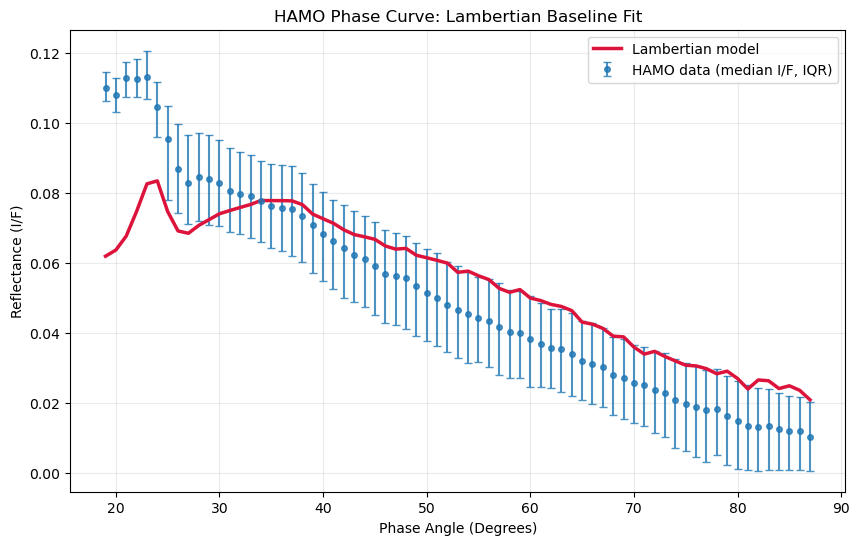

In [15]:
hamo_x = df_hamo["phase_bin_deg"].to_numpy(dtype=float)
hamo_order = np.argsort(hamo_x)
hamo_x_sorted = hamo_x[hamo_order]
hamo_observed_sorted = hamo_observed[hamo_order]
hamo_predicted_sorted = hamo_predicted[hamo_order]
hamo_yerr_lower = (hamo_observed - df_hamo["iof_q25"].to_numpy(dtype=float))[hamo_order]
hamo_yerr_upper = (df_hamo["iof_q75"].to_numpy(dtype=float) - hamo_observed)[hamo_order]
hamo_yerr = np.vstack([hamo_yerr_lower, hamo_yerr_upper])

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(
    hamo_x_sorted,
    hamo_observed_sorted,
    yerr=hamo_yerr,
    fmt="o",
    markersize=4,
    capsize=3,
    alpha=0.8,
    label="HAMO data (median I/F, IQR)",
)
ax.plot(
    hamo_x_sorted,
    hamo_predicted_sorted,
    color="crimson",
    linewidth=2.5,
    label="Lambertian model",
)

ax.set_xlabel("Phase Angle (Degrees)")
ax.set_ylabel("Reflectance (I/F)")
ax.set_title("HAMO Phase Curve: Lambertian Baseline Fit")
ax.legend()
ax.grid(True, alpha=0.25)

plt.show()

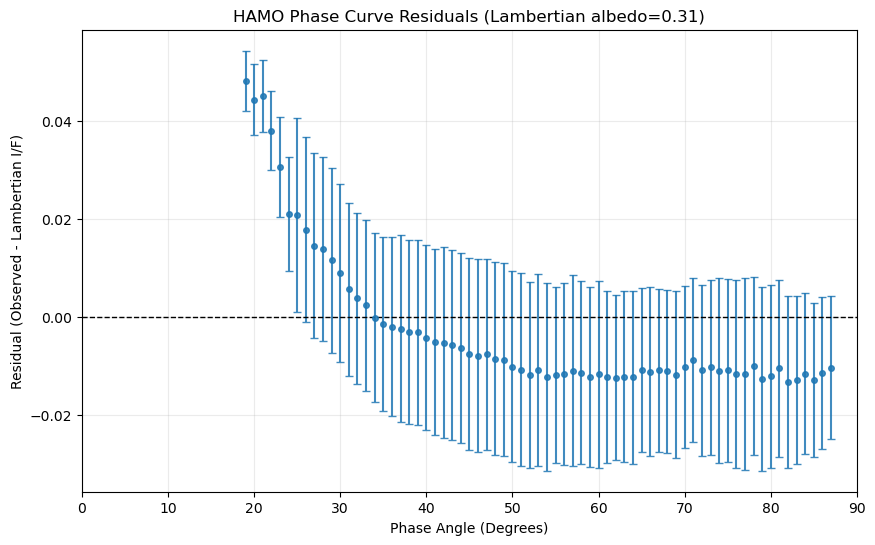

HAMO Mean residuals (I/F): <15deg=nan, 15-45deg=1.029884e-02, >45deg=-1.118007e-02


In [16]:
hamo_mu0 = np.cos(hamo_mean_incidence_rad)

# Lambertian predicted I/F = albedo * mu0 / pi
hamo_pred_lambert = hamo_fitted_albedo * hamo_mu0 / np.pi
hamo_observed = df_hamo['median_iof'].to_numpy(dtype=float) # Convert to numpy array
hamo_residuals = hamo_observed - hamo_pred_lambert


# Uncertainty estimate from IQR -> sigma ~= IQR / 1.35
hamo_iqr = df_hamo['iof_q75'].to_numpy(dtype=float) - df_hamo['iof_q25'].to_numpy(dtype=float)
hamo_sigma = hamo_iqr / 1.35

# Plot residuals vs phase with symmetric error bars using sigma
hamo_x = df_hamo['phase_bin_deg'].to_numpy(dtype=float)
hamo_order = np.argsort(hamo_x)
hamo_x_sorted = hamo_x[hamo_order]
hamo_res_sorted = hamo_residuals[hamo_order]
hamo_yerr = hamo_sigma[hamo_order]

fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(hamo_x_sorted, hamo_res_sorted, yerr=hamo_yerr, fmt='o', markersize=4, capsize=3, alpha=0.85)
ax.axhline(0.0, color='k', linestyle='--', linewidth=1)
ax.set_xlim(0, 90)
ax.set_xlabel('Phase Angle (Degrees)')
ax.set_ylabel('Residual (Observed - Lambertian I/F)')
ax.set_title('HAMO Phase Curve Residuals (Lambertian albedo={:.2f})'.format(hamo_fitted_albedo))
ax.grid(True, alpha=0.25)
plt.show()

# Compute mean residuals in three phase ranges

hamo_mask1 = hamo_x_sorted < 15
hamo_mask2 = (hamo_x_sorted >= 15) & (hamo_x_sorted <= 45)
hamo_mask3 = hamo_x_sorted > 45
hamo_mean1 = np.mean(hamo_res_sorted[hamo_mask1]) if np.any(hamo_mask1) else np.nan
hamo_mean2 = np.mean(hamo_res_sorted[hamo_mask2]) if np.any(hamo_mask2) else np.nan
hamo_mean3 = np.mean(hamo_res_sorted[hamo_mask3]) if np.any(hamo_mask3) else np.nan
print(f"HAMO Mean residuals (I/F): <15deg={hamo_mean1:.6e}, 15-45deg={hamo_mean2:.6e}, >45deg={hamo_mean3:.6e}")



LAMO

In [17]:
df_lamo = df_lamo[df_lamo['median_iof'] > 0.01].dropna()

lamo_mean_incidence_rad = df_lamo["mean_incidence"].to_numpy(dtype=float) * (np.pi / 180.0) # Convert degrees to radians
lamo_mean_emission_rad = df_lamo["mean_emission"].to_numpy(dtype=float) * (np.pi / 180.0) # Convert degrees to radians
lamo_mean_phase_rad = df_lamo["mean_phase"].to_numpy(dtype=float) * (np.pi / 180.0)     # Convert degrees to radians

lamo_geometry_batch = GeometryBatch(
    incidence=lamo_mean_incidence_rad,
    emission=lamo_mean_emission_rad,
    phase=lamo_mean_phase_rad,
)


lamo_observed = df_lamo["median_iof"].to_numpy(dtype=float)

lamo_fit_result = fitter.fit(model, lamo_geometry_batch, lamo_observed)

lamo_fitted_albedo = lamo_fit_result.fitted_parameters["albedo"]

print("Fitted albedo LAMO:", lamo_fitted_albedo)

model.parameters.update(lamo_fit_result.fitted_parameters)
lamo_predicted = np.asarray(model.reflectance(lamo_geometry_batch), dtype=float)

Fitted albedo LAMO: 0.29858068527750325


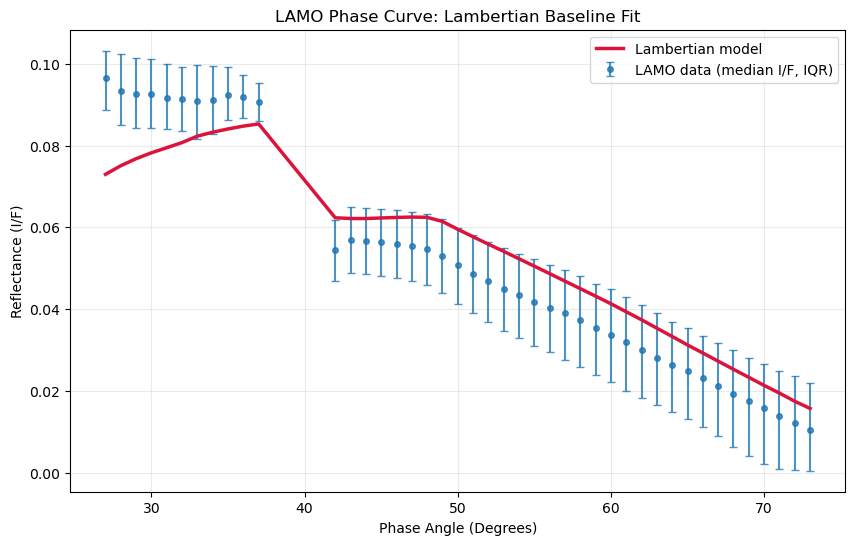

In [18]:
lamo_x = df_lamo["phase_bin_deg"].to_numpy(dtype=float)
lamo_order = np.argsort(lamo_x)
lamo_x_sorted = lamo_x[lamo_order]
lamo_observed_sorted = lamo_observed[lamo_order]
lamo_predicted_sorted = lamo_predicted[lamo_order]
lamo_yerr_lower = (lamo_observed - df_lamo["iof_q25"].to_numpy(dtype=float))[lamo_order]
lamo_yerr_upper = (df_lamo["iof_q75"].to_numpy(dtype=float) - lamo_observed)[lamo_order]
lamo_yerr = np.vstack([lamo_yerr_lower, lamo_yerr_upper])

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(
    lamo_x_sorted,
    lamo_observed_sorted,
    yerr=lamo_yerr,
    fmt="o",
    markersize=4,
    capsize=3,
    alpha=0.8,
    label="LAMO data (median I/F, IQR)",
)
ax.plot(
    lamo_x_sorted,
    lamo_predicted_sorted,
    color="crimson",
    linewidth=2.5,
    label="Lambertian model",
)

ax.set_xlabel("Phase Angle (Degrees)")
ax.set_ylabel("Reflectance (I/F)")
ax.set_title("LAMO Phase Curve: Lambertian Baseline Fit")
ax.legend()
ax.grid(True, alpha=0.25)

plt.show()

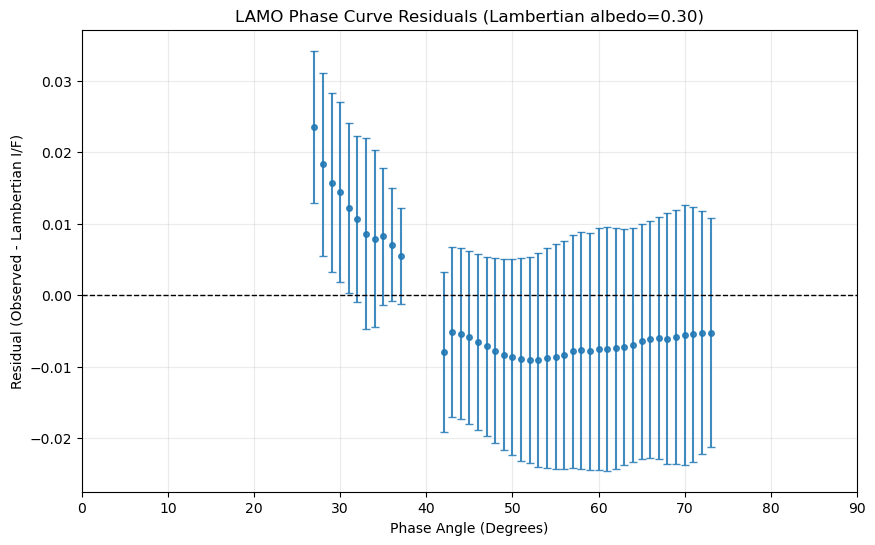

LAMO Mean residuals (I/F): <15deg=nan, 15-45deg=7.173703e-03, >45deg=-7.272473e-03


In [19]:
lamo_mu0 = np.cos(lamo_mean_incidence_rad)

# Lambertian predicted I/F = albedo * mu0 / pi
lamo_pred_lambert = lamo_fitted_albedo * lamo_mu0 / np.pi
lamo_observed = df_lamo['median_iof'].to_numpy(dtype=float) # Convert to numpy array
lamo_residuals = lamo_observed - lamo_pred_lambert


# Uncertainty estimate from IQR -> sigma ~= IQR / 1.35
lamo_iqr = df_lamo['iof_q75'].to_numpy(dtype=float) - df_lamo['iof_q25'].to_numpy(dtype=float)
lamo_sigma = lamo_iqr / 1.35

# Plot residuals vs phase with symmetric error bars using sigma
lamo_x = df_lamo['phase_bin_deg'].to_numpy(dtype=float)
lamo_order = np.argsort(lamo_x)
lamo_x_sorted = lamo_x[lamo_order]
lamo_res_sorted = lamo_residuals[lamo_order]
lamo_yerr = lamo_sigma[lamo_order]

fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(lamo_x_sorted, lamo_res_sorted, yerr=lamo_yerr, fmt='o', markersize=4, capsize=3, alpha=0.85)
ax.axhline(0.0, color='k', linestyle='--', linewidth=1)
ax.set_xlim(0, 90)
ax.set_xlabel('Phase Angle (Degrees)')
ax.set_ylabel('Residual (Observed - Lambertian I/F)')
ax.set_title('LAMO Phase Curve Residuals (Lambertian albedo={:.2f})'.format(lamo_fitted_albedo))
ax.grid(True, alpha=0.25)
plt.show()

# Compute mean residuals in three phase ranges

lamo_mask1 = lamo_x_sorted < 15
lamo_mask2 = (lamo_x_sorted >= 15) & (lamo_x_sorted <= 45)
lamo_mask3 = lamo_x_sorted > 45
lamo_mean1 = np.mean(lamo_res_sorted[lamo_mask1]) if np.any(lamo_mask1) else np.nan
lamo_mean2 = np.mean(lamo_res_sorted[lamo_mask2]) if np.any(lamo_mask2) else np.nan
lamo_mean3 = np.mean(lamo_res_sorted[lamo_mask3]) if np.any(lamo_mask3) else np.nan
print(f"LAMO Mean residuals (I/F): <15deg={lamo_mean1:.6e}, 15-45deg={lamo_mean2:.6e}, >45deg={lamo_mean3:.6e}")



In [24]:
# Isolate <15° regime for RC and Survey
rc_low_phase = df_rc[df_rc['phase_bin_deg'] < 15].copy()
survey_low_phase = df_survey[df_survey['phase_bin_deg'] < 15].copy()

# Calculate Lommel-Seeliger disk function for RC
rc_low_phase_mean_incidence_rad = np.deg2rad(rc_low_phase['mean_incidence'].values)
rc_low_phase_mean_emission_rad = np.deg2rad(rc_low_phase['mean_emission'].values)
rc_low_phase_mu0 = np.cos(rc_low_phase_mean_incidence_rad)
rc_low_phase_mu = np.cos(rc_low_phase_mean_emission_rad)
rc_disk_func = rc_low_phase_mu0 / (rc_low_phase_mu0 + rc_low_phase_mu)
rc_low_phase['disk_corrected_iof'] = rc_low_phase['median_iof'] / rc_disk_func

# Calculate Lommel-Seeliger disk function for Survey
survey_low_phase_mean_incidence_rad = np.deg2rad(survey_low_phase['mean_incidence'].values)
survey_low_phase_mean_emission_rad = np.deg2rad(survey_low_phase['mean_emission'].values)
survey_low_phase_mu0 = np.cos(survey_low_phase_mean_incidence_rad)
survey_low_phase_mu = np.cos(survey_low_phase_mean_emission_rad)
survey_disk_func = survey_low_phase_mu0 / (survey_low_phase_mu0 + survey_low_phase_mu)
survey_low_phase['disk_corrected_iof'] = survey_low_phase['median_iof'] / survey_disk_func

# Display results
print("=" * 120)
print("RC PHASE: <15° OPPOSITION REGIME - LOMMEL-SEELIGER DISK FUNCTION CORRECTION")
print("=" * 120)
print(rc_low_phase[['phase_bin_deg', 'median_iof', 'mean_incidence', 'mean_emission', 'n_pixels', 'disk_corrected_iof']].to_string())

print("\n" + "=" * 120)
print("SURVEY PHASE: <15° OPPOSITION REGIME - LOMMEL-SEELIGER DISK FUNCTION CORRECTION")
print("=" * 120)
print(survey_low_phase[['phase_bin_deg', 'median_iof', 'mean_incidence', 'mean_emission', 'n_pixels', 'disk_corrected_iof']].to_string())

RC PHASE: <15° OPPOSITION REGIME - LOMMEL-SEELIGER DISK FUNCTION CORRECTION
    phase_bin_deg  median_iof  mean_incidence  mean_emission  n_pixels  disk_corrected_iof
0             5.0    0.153111       71.626347      66.758334    176610            0.344788
1             5.5    0.156039       63.232285      58.376821    666541            0.337700
2             6.0    0.158313       56.575414      51.795269   1161459            0.336065
3             6.5    0.158304       51.476546      46.875979   1672728            0.332046
4             7.0    0.157746       47.177785      42.928023   2181162            0.327673
5             7.5    0.156670       43.457700      39.861136   2659699            0.322344
6             8.0    0.155345       40.491482      38.185382   3092602            0.315901
7             8.5    0.154194       38.795879      38.158405   3466045            0.309757
8             9.0    0.152791       38.610778      39.477007   3765098            0.303720
9             

In [25]:
# Compact summary of Lommel-Seeliger correction
import numpy as _np
for name, df in [("RC", rc_low_phase), ("Survey", survey_low_phase)]:
    if df.empty:
        print(f"{name}: no rows")
        continue
    disk = df['disk_corrected_iof'].to_numpy(dtype=float)
    raw = df['median_iof'].to_numpy(dtype=float)
    print(f"{name}: rows={len(df)}; mean(disk_corr)={_np.nanmean(disk):.6e}; median(disk_corr)={_np.nanmedian(disk):.6e}; min={_np.nanmin(disk):.6e}; max={_np.nanmax(disk):.6e}; mean(raw)={_np.nanmean(raw):.6e}; delta_mean={( _np.nanmean(disk)-_np.nanmean(raw) ): .6e}")


RC: rows=20; mean(disk_corr)=2.796698e-01; median(disk_corr)=2.877618e-01; min=1.513542e-01; max=3.447882e-01; mean(raw)=1.389903e-01; delta_mean= 1.406796e-01
Survey: rows=7; mean(disk_corr)=2.742593e-01; median(disk_corr)=2.727177e-01; min=2.686694e-01; max=2.801368e-01; mean(raw)=1.321051e-01; delta_mean= 1.421542e-01
